#SCRAP, PRE PROCESS DATA

In [ ]:
!pip install google-play-scraper pandas tqdm langdetect deep-translator transformers torch emoji contractions gensim Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 24.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=99dbf8cd8fb1d8221c4900a016bd147249cd57c90062e417f12cb8e16d8ad054
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd
from tqdm import tqdm
import datetime

app_id = "com.bibit.bibitid"
all_reviews = []
cursor = None

print("🚀 Scraping all possible reviews...")

while True:
    result, cursor = reviews(
        app_id,
        lang="id",
        country="id",
        sort=Sort.MOST_RELEVANT,
        count=200,
        continuation_token=cursor
    )

    if not result:
        break

    all_reviews.extend(result)

    if cursor is None:
        break

    if len(all_reviews) >= 50000:  # buffer besar
        break

print(f"Total scraped: {len(all_reviews)}")

🚀 Scraping all possible reviews...
Total scraped: 43623


filter time stamp, jumlah kata

In [ ]:
import pandas as pd

# ====== 1. DATA MENTAH ======
df_raw = pd.DataFrame(all_reviews)
df_raw["at"] = pd.to_datetime(df_raw["at"])

# ====== 2. FILTER TIMESTAMP (JAN 2022 – DES 2025) ======
start_date = pd.Timestamp("2021-01-01")
end_date   = pd.Timestamp("2025-01-31")

df_time = df_raw[
    (df_raw["at"] >= start_date) &
    (df_raw["at"] <= end_date)
].copy()

print("After time filter:", len(df_time))

# ====== 3. HITUNG JUMLAH KATA ======
df_time["wc_raw"] = (
    df_time["content"]
    .astype(str)
    .str.split()
    .str.len()
)

# ====== 4. FILTER MIN KATA ======
MIN_WORDS = 5

df_final = df_time[df_time["wc_raw"] >= MIN_WORDS].copy()

print(f"After min {MIN_WORDS} words filter:", len(df_final))

df_final.head(5)

After time filter: 12342
After min 5 words filter: 6603


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,wc_raw
271,c8fc175e-3bed-407a-bd76-1e2426a4cf50,Ravindra A.P,https://play-lh.googleusercontent.com/a-/ALV-U...,Aplikasi bibit sangat memudahkan untuk investa...,1,4,None,2023-03-02 22:33:01,"Hai kak, terima kasih atas feedback yg diberik...",2023-03-03 04:55:10,None,68
289,a03889af-6e0d-42fc-9121-ddbef7f7abc0,Yumn (Yumi),https://play-lh.googleusercontent.com/a/ACg8oc...,Sbnrnya sya suka dngan konsep nabung saham & o...,4,52,3.76.1,2024-03-01 05:14:52,None,NaT,3.76.1,75
313,cd5460ca-e739-4860-b76a-778bcc83cc82,Rezy Marsellina,https://play-lh.googleusercontent.com/a-/ALV-U...,Pengalaman saya dan pembelajaran buat semua: M...,1,24,3.21.0,2022-01-08 03:18:57,"Hai kak, dana penjualan mengikuti NAV yg kakak...",2022-01-08 15:15:35,3.21.0,64
321,4c6d17e6-bf8f-409a-bc7e-85d165176f4a,opeT Gaming,https://play-lh.googleusercontent.com/a-/ALV-U...,"Daftarnya bener² ribet bnget, ntah dari tahap ...",2,24,3.79.0,2024-05-28 14:37:07,Hai kak. Untuk masalah registrasi bisa langsun...,2024-05-29 03:28:03,3.79.0,67
334,7499a0b2-bf2d-4409-ab91-0c730024e543,Anggie Risana,https://play-lh.googleusercontent.com/a-/ALV-U...,Awalnya pencairan lancar waktu pertama ... skr...,1,4,None,2022-07-19 12:01:53,"Hai kak, jika dana penjualan kakak belum diter...",2022-07-19 14:26:11,None,54


In [ ]:
df_final.to_csv(
    "bibit_reviews_indonesian.csv",
    index=False,
    encoding="utf-8"
)

preproses

mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#case folding

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/skripsi/bibit_reviews_indonesian_new.csv")
df['case_folding'] = df['content'].str.lower()

In [ ]:
#cleaning data
import re

def clean_text(text):
    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus HTML
    text = re.sub(r'<.*?>', '', text)

    # hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # hapus emoji
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # hapus tanda baca (termasuk .... !!! ,,,)
    text = re.sub(r'[^\w\s]', '', text)

    # hapus karakter aneh
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    return text

# terapkan cleaning
df['cleaning'] = df['case_folding'].apply(clean_text)

print("Cleaning selesai:", len(df))

Cleaning selesai: 10143


In [ ]:
#normalisasi
# load kamus
kamus = {}
with open("/content/drive/MyDrive/skripsi/kamus_normalisasi.txt", "r", encoding="utf-8") as f:
    for line in f:
        kata = line.strip().split(",")
        if len(kata) == 2:
            kamus[kata[0].strip()] = kata[1].strip()

# fungsi normalisasi
def normalize_text(text):
    # pisahkan kata & tanda baca
    tokens = re.findall(r'\w+|[^\w\s]', text)

    # normalisasi kata
    tokens = [kamus[token] if token in kamus else token for token in tokens]

    # gabungkan kembali
    text = " ".join(tokens)

    # rapikan spasi sebelum tanda baca
    text = re.sub(r'\s+([?.!,])', r'\1', text)

    return text

df['cleaning'] = df['cleaning'].apply(normalize_text)

# terapkan
df['normalisasi'] = df['cleaning'].apply(normalize_text)
print("Normalisasi selesai")

df.to_csv('/content/drive/MyDrive/skripsi/bibit_reviews_normal.csv', index=False)

Normalisasi selesai


In [ ]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# stopword bawaan
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

# custom stopword (single word)
custom_stopwords = {
    "yang", "dan", "di", "ke", "dari",
    "aja", "nih", "sih", "dong", "kok", "lah",
    "nya", "deh", "tuh", "kan", "tidak",
    "aku", "saya", "kamu", "dia", "mereka",
    "admin", "kak", "kakak", "sekali",
    "udah", "sudah", "belum", "jadi", "tibatiba",
    "banget", "doang", "saja", "kadangkadang",
    "dll", "dsb", "mudahmudahan", "padahal",
    "rt", "via", "mudahmudah", "garagara"
}

# multi-word stopwords
multi_stopwords = {
    "dan lain-lain",
    "dan lain sebagainya",
    "tiba tiba",
    "kadang kadang",
    "mudah mudahan",
    "tibatiba tibatiba",
    "tiba-tiba",
    "kadang-kadang",
    "mudah mudah",
    "mudah-mudahan",
    "mudah-mudah an",
    "mudah-mudah",
    "mudah mudahmudahan",
    "dana dana",
    "gara gara",
    "gara-gara"
}

# Suffix untuk dihapus
suffixes_to_remove = ["nya", "kan", "ku", "mu", "kah", "pun"]

# Kata dasar minimal 3 huruf
MIN_WORD_LENGTH = 3

# Gabungkan stopwords
all_stopwords = stopwords.union(custom_stopwords)

def remove_suffixes_from_word(word):
    """Hapus suffix dari kata (hanya sekali)"""
    word_lower = word.lower()

    for suffix in suffixes_to_remove:
        if word_lower.endswith(suffix):
            stripped_length = len(word_lower) - len(suffix)
            if stripped_length >= MIN_WORD_LENGTH:
                # Cek khusus: jangan hapus "i" dari "kami", "sini", "dari"
                if suffix == "i" and stripped_length == 3:
                    # Kata seperti "dari" (4 huruf) - suffix "i" -> "dar" (3 huruf)
                    # Biarkan saja jika memang cocok
                    pass
                return word_lower[:-len(suffix)]

    return word_lower

def remove_stopwords(text):
    # Handle berbagai tipe input
    if pd.isna(text):
        return ""
    if not isinstance(text, str):
        text = str(text)

    # Bersihkan karakter aneh
    text = text.strip()
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = text.replace('\t', ' ')

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Hapus tanda baca (tapi pertahankan spasi)
    text = re.sub(r'[^\w\s-]', ' ', text)

    # Step 3: Hapus multi-word stopwords
    for phrase in multi_stopwords:
        # Pattern dengan variasi spasi
        pattern = re.escape(phrase).replace(r'\ ', r'[\s-]+')
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)

    # Step 4: Bersihkan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Proses per kata
    words = text.split()
    filtered_words = []

    for word in words:
        if not word or len(word) < 2:
            continue

        # Hapus suffix
        word_stripped = remove_suffixes_from_word(word)

        # Cek stopword
        if word_stripped in all_stopwords:
            continue

        # Kasus khusus "gara"
        if word_stripped == "gara":
            continue

        # Simpan hasil
        filtered_words.append(word_stripped if word_stripped != word else word)

    result = " ".join(filtered_words)
    result = re.sub(r'\s+', ' ', result).strip()

    return result

# Terapkan ke dataframe dengan progress bar
from tqdm import tqdm
tqdm.pandas()

print("Memproses stopword removal...")
df['stopword'] = df['normalisasi'].progress_apply(remove_stopwords)

# VERIFIKASI HASIL
print("\n=== VERIFIKASI HASIL ===")
print("Contoh perbandingan:")
for idx in range(min(10, len(df))):
    original = df.iloc[idx]['normalisasi']
    result = df.iloc[idx]['stopword']
    print(f"\n{idx+1}. Original: {original}")
    print(f"   Result:   {result}")
    print(f"   Sama? {'✓' if original != result else '✗ (tidak berubah)'}")

Memproses stopword removal...


100%|██████████| 10143/10143 [00:00<00:00, 10428.02it/s]


=== VERIFIKASI HASIL ===
Contoh perbandingan:

1. Original: aplikasi bibit sangat memudahkan untuk investasi surat berharga negara namun dari segi aksesibilitas masih belum ramah untuk disabilitas netra saat bernavigasi menggunakan talkback di dalam bibit beberapa menu tidak bisa di akses misalnya untuk menentukan tanggal tahun dan bulan tidak bisa di klik sedangkan saudaranya yaitu stockbit hampir semua menu bisa di akses dengan pembaca layar talkback bicara - bicara talkback sekarang berubah nama jadi android accessibility beralih semoga ke depan ada perbaikan di bibit
   Result:   aplikasi bibit sangat memudah investasi surat berharga negara segi aksesibilitas ramah disabilitas netra bernavigasi mengguna talkback bibit beberapa menu akses misal menentu tanggal tahun bulan klik sedang saudara stockbit hampir semua menu akses pembaca layar talkback bicara bicara talkback sekarang berubah nama android accessibility beralih semoga depan perbai bibit
   Sama? ✓

2. Original: sebenarnya 

In [ ]:
# Test
if __name__ == "__main__":
    test_cases = [
        "aplikasinya bagus sekali",
        "penarikannya cepat",
        "gara-gara dia datang terlambat",
        "gara gara hujan deras",
        "bukunya saya baca",
        "jalannya macet parah",
        "makannya lahap banget",
        "dana dana ini untuk acara",
        "tiba-tiba dia pergi",
        "mudah-mudahan lulus",
        "keuntungannya setelah"
    ]

    print("=== TEST REMOVE STOPWORDS (FIXED) ===")
    for test in test_cases:
        result = remove_stopwords(test)
        print(f"Input : {test}")
        print(f"Output: {result}")
        print("-" * 50)

=== TEST REMOVE STOPWORDS (FIXED) ===
Input : aplikasinya bagus sekali
Output: aplikasi bagus
--------------------------------------------------
Input : penarikannya cepat
Output: penarikan cepat
--------------------------------------------------
Input : gara-gara dia datang terlambat
Output: datang terlambat
--------------------------------------------------
Input : gara gara hujan deras
Output: hujan deras
--------------------------------------------------
Input : bukunya saya baca
Output: buku baca
--------------------------------------------------
Input : jalannya macet parah
Output: jalan macet parah
--------------------------------------------------
Input : makannya lahap banget
Output: makan lahap
--------------------------------------------------
Input : dana dana ini untuk acara
Output: acara
--------------------------------------------------
Input : tiba-tiba dia pergi
Output: pergi
--------------------------------------------------
Input : mudah-mudahan lulus
Output: an lulu

In [ ]:
#save csv
df.to_csv("/content/drive/MyDrive/skripsi/bibit_reviews_clean_stopword.csv",index=False)

print("Jumlah data akhir:", len(df))

Jumlah data akhir: 10143


In [ ]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,wc_raw,Unnamed: 12,case_folding,cleaning,normalisasi,stopword,lang_id,is_spam
0,c8fc175e-3bed-407a-bd76-1e2426a4cf50,Ravindra A.P,https://play-lh.googleusercontent.com/a-/ALV-U...,Aplikasi bibit sangat memudahkan untuk investa...,1,4,NaN,2023-03-02 22:33:01,"Hai kak, terima kasih atas feedback yg diberik...",2023-03-03 4:55:10,NaN,68,NaN,aplikasi bibit sangat memudahkan untuk investa...,aplikasi bibit sangat memudahkan untuk investa...,aplikasi bibit sangat memudahkan untuk investa...,aplikasi bibit sangat memudah investasi surat ...,id,False
1,a03889af-6e0d-42fc-9121-ddbef7f7abc0,Yumn (Yumi),https://play-lh.googleusercontent.com/a/ACg8oc...,Sbnrnya sya suka dngan konsep nabung saham & o...,4,52,3.76.1,2024-03-01 5:14:52,NaN,NaN,3.76.1,75,NaN,sbnrnya sya suka dngan konsep nabung saham & o...,sebenarnya saya suka dengan konsep menabung sa...,sebenarnya saya suka dengan konsep menabung sa...,sebenar suka konsep menabung saham obligasi 10...,id,False
2,4c6d17e6-bf8f-409a-bc7e-85d165176f4a,opeT Gaming,https://play-lh.googleusercontent.com/a-/ALV-U...,"Daftarnya bener² ribet bnget, ntah dari tahap ...",2,24,3.79.0,2024-05-28 14:37:07,Hai kak. Untuk masalah registrasi bisa langsun...,2024-05-29 3:28:03,3.79.0,67,NaN,"daftarnya bener² ribet bnget, ntah dari tahap ...",mendaftarnya benar rumit sekali entah dari tah...,mendaftarnya benar rumit sekali entah dari tah...,mendaftar benar rumit entah tahap pertama taha...,id,False
3,b4802bce-8ae2-439d-94d7-840c523958d3,Win,https://play-lh.googleusercontent.com/a-/ALV-U...,Aplikasinya mudah sangat digunakan dan banyak ...,5,3,NaN,2022-12-25 2:03:32,NaN,NaN,NaN,42,NaN,aplikasinya mudah sangat digunakan dan banyak ...,aplikasinya mudah sangat digunakan dan banyak ...,aplikasinya mudah sangat digunakan dan banyak ...,aplikasi mudah sangat diguna banyak pilihan pr...,id,False
4,8a4dafe5-b4c4-4151-be2d-f609aec98e19,krisnanti angela,https://play-lh.googleusercontent.com/a-/ALV-U...,Sudah pakai bibit 2 tahunan dulu takut takut m...,4,354,3.71.5,2023-12-13 15:09:17,NaN,NaN,3.71.5,62,NaN,sudah pakai bibit 2 tahunan dulu takut takut m...,sudah pakai bibit 2 tahunan dahulu takut takut...,sudah pakai bibit 2 tahunan dahulu takut takut...,pakai bibit tahunan takut takut coba sekarang ...,id,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9314,61bd9d04-a079-4d1f-b2df-a8732470346f,Ryan Saefulrochman,https://play-lh.googleusercontent.com/a-/ALV-U...,Kenapa interface aplikasi saya error ya?,4,0,NaN,2021-11-08 7:00:25,NaN,NaN,NaN,6,NaN,kenapa interface aplikasi saya error ya?,kenapa antarmuka aplikasi saya error ya,kenapa antarmuka aplikasi saya error ya,antarmuka aplikasi error,id,False
9315,9f58a374-61fe-4225-a860-cd8bc76f0513,Mumtaz,https://play-lh.googleusercontent.com/a-/ALV-U...,Smoga Desember dapat return 10jt ...,5,0,NaN,2022-07-01 13:48:23,NaN,NaN,NaN,6,NaN,smoga desember dapat return 10jt ...,semoga desember dapat return 10 juta,semoga desember dapat return 10 juta,semoga desember return 10 juta,id,False
9316,460587d9-38eb-4126-a6fc-740aa0b97ac8,MUHAMMAD FARIDZ RAMADHAN,https://play-lh.googleusercontent.com/a-/ALV-U...,"Respon nya cepat bat, i like bibit",5,1,NaN,2021-05-28 12:03:35,NaN,NaN,NaN,11,NaN,"respon nya cepat bat, i like bibit",respon nya cepat sekali i like bibit,respon nya cepat sekali i like bibit,respon cepat like bibit,id,False
9317,83036ae1-158a-4365-816e-6d5419992ea9,rezi Indonesia,https://play-lh.googleusercontent.com/a/ACg8oc...,Msh baru so far so good,5,0,NaN,2022-07-15 6:19:31,NaN,NaN,NaN,6,NaN,msh baru so far so good,masih baru sangat far sangat bagus,masih baru sangat far sangat bagus,baru sangat far sangat bagus,id,False


In [ ]:
#cek dan filter bahasa
from langdetect import detect

def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

# deteksi bahasa
df['lang_id'] = df['normalisasi'].apply(detect_lang)

# jumlah sebelum
before_count = len(df)

# filter hanya Indonesia
df = df[df['lang_id'] == 'id']

# jumlah sesudah
after_count = len(df)

# tampilkan hasil
print("Jumlah sebelum filter bahasa:", before_count)
print("Jumlah setelah filter bahasa:", after_count)
print("Jumlah data terhapus:", before_count - after_count)

Jumlah sebelum filter bahasa: 10143
Jumlah setelah filter bahasa: 10018
Jumlah data terhapus: 125


In [ ]:
#hapus duplikat
df = df.drop_duplicates(subset=['normalisasi'])

#hapus hanya simbol
df = df[df['normalisasi'].str.contains(r'[A-Za-z0-9]', regex=True)]

#hapus karakter berulang
df = df[~df['normalisasi'].str.contains(r'(.)\1{3,}', regex=True)]

#minimal kata
df = df[df['normalisasi'].str.split().str.len() >= 5]

print("Jumlah akhir setelah semua filtering:", len(df))

Jumlah akhir setelah semua filtering: 9839


/tmp/ipykernel_3563/1034120918.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df['normalisasi'].str.contains(r'(.)\1{3,}', regex=True)]


In [ ]:
import pandas as pd
import re

def clean_bibit_reviews_pipeline():

    # kata kunci spam
    spam_keywords = [
        # kode & referral
        'pakai kode', 'gunakan kode', 'kode referral', 'kode referal',
        'kode promo', 'kode undangan', 'kode saya', 'referral',
        'cashback', 'uang gratis', 'bonus', 'voucher', 'diskon',
        'hadiah', 'gratis saldo', 'saldo gratis', 'cash back',
        'daftar sekarang', 'gabung sekarang', 'ayo daftar',
        'klik di sini', 'klik link', 'join sekarang', 'gabung', 'join',
        'hubungi saya', 'chat saya', 'dm saya',
        'wa saya', 'whatsapp saya', 'kontak saya',
        'pasti untung', 'dijamin untung', 'tanpa risiko',
        'cepat kaya', 'cuan cepat',
        'giveaway', 'bagi bagi', 'bagi-bagi',
        'kode', 'kodeku', 'referralku'
    ]

    # fungsi deteksi spam
    def is_spam(text):
        text = str(text).lower()

        # kosong
        if text.strip() == '' or pd.isna(text):
            return True

        # keyword spam
        if any(k in text for k in spam_keywords):
            return True

        # mengandung URL/link
        if re.search(r'http\S+|www\S+', text):
            return True

        # terlalu banyak angka
        if sum(c.isdigit() for c in text) > 10:
            return True

        # terlalu sedikit kata bermakna
        if len([w for w in text.split() if len(w) > 2]) < 3:
            return True

        # karakter berulang (contoh: baguuuussssss)
        if re.search(r'(.)\1{3,}', text):
            return True

        # simbol/emoji berlebihan
        if len(re.findall(r'[^\w\s,]', text)) > 10:
            return True

        return False

    # deteksi spam
    df['is_spam'] = df['normalisasi'].apply(is_spam)

    # pisahkan data
    clean_df = df.loc[~df['is_spam']].copy()
    spam_df  = df.loc[df['is_spam']].copy()

    # output info
    print(f"Total reviews : {len(df)}")
    print(f"Clean reviews : {len(clean_df)}")
    print(f"Spam reviews  : {len(spam_df)}")

    return clean_df, spam_df


# jalankan
clean_df, spam_df = clean_bibit_reviews_pipeline()

Total reviews : 9839
Clean reviews : 9318
Spam reviews  : 521


In [ ]:
#save csv
clean_df.to_csv("/content/drive/MyDrive/skripsi/bibit_reviews_clean_final.csv",index=False)

print("Jumlah data akhir:", len(clean_df))

Jumlah data akhir: 9318


In [ ]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,wc_raw,Unnamed: 12,case_folding,cleaning,normalisasi,stopword,lang_id,is_spam
0,c8fc175e-3bed-407a-bd76-1e2426a4cf50,Ravindra A.P,https://play-lh.googleusercontent.com/a-/ALV-U...,Aplikasi bibit sangat memudahkan untuk investa...,1,4,NaN,2023-03-02 22:33:01,"Hai kak, terima kasih atas feedback yg diberik...",2023-03-03 4:55:10,NaN,68,NaN,aplikasi bibit sangat memudahkan untuk investa...,aplikasi bibit sangat memudahkan untuk investa...,aplikasi bibit sangat memudahkan untuk investa...,aplikasi bibit sangat memudah investasi surat ...,id,False
1,a03889af-6e0d-42fc-9121-ddbef7f7abc0,Yumn (Yumi),https://play-lh.googleusercontent.com/a/ACg8oc...,Sbnrnya sya suka dngan konsep nabung saham & o...,4,52,3.76.1,2024-03-01 5:14:52,NaN,NaN,3.76.1,75,NaN,sbnrnya sya suka dngan konsep nabung saham & o...,sebenarnya saya suka dengan konsep menabung sa...,sebenarnya saya suka dengan konsep menabung sa...,sebenar suka konsep menabung saham obligasi 10...,id,False
3,4c6d17e6-bf8f-409a-bc7e-85d165176f4a,opeT Gaming,https://play-lh.googleusercontent.com/a-/ALV-U...,"Daftarnya bener² ribet bnget, ntah dari tahap ...",2,24,3.79.0,2024-05-28 14:37:07,Hai kak. Untuk masalah registrasi bisa langsun...,2024-05-29 3:28:03,3.79.0,67,NaN,"daftarnya bener² ribet bnget, ntah dari tahap ...",mendaftarnya benar rumit sekali entah dari tah...,mendaftarnya benar rumit sekali entah dari tah...,mendaftar benar rumit entah tahap pertama taha...,id,False
6,b4802bce-8ae2-439d-94d7-840c523958d3,Win,https://play-lh.googleusercontent.com/a-/ALV-U...,Aplikasinya mudah sangat digunakan dan banyak ...,5,3,NaN,2022-12-25 2:03:32,NaN,NaN,NaN,42,NaN,aplikasinya mudah sangat digunakan dan banyak ...,aplikasinya mudah sangat digunakan dan banyak ...,aplikasinya mudah sangat digunakan dan banyak ...,aplikasi mudah sangat diguna banyak pilihan pr...,id,False
7,8a4dafe5-b4c4-4151-be2d-f609aec98e19,krisnanti angela,https://play-lh.googleusercontent.com/a-/ALV-U...,Sudah pakai bibit 2 tahunan dulu takut takut m...,4,354,3.71.5,2023-12-13 15:09:17,NaN,NaN,3.71.5,62,NaN,sudah pakai bibit 2 tahunan dulu takut takut m...,sudah pakai bibit 2 tahunan dahulu takut takut...,sudah pakai bibit 2 tahunan dahulu takut takut...,pakai bibit tahunan takut takut coba sekarang ...,id,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10133,9f58a374-61fe-4225-a860-cd8bc76f0513,Mumtaz,https://play-lh.googleusercontent.com/a-/ALV-U...,Smoga Desember dapat return 10jt ...,5,0,NaN,2022-07-01 13:48:23,NaN,NaN,NaN,6,NaN,smoga desember dapat return 10jt ...,semoga desember dapat return 10 juta,semoga desember dapat return 10 juta,semoga desember return 10 juta,id,False
10136,460587d9-38eb-4126-a6fc-740aa0b97ac8,MUHAMMAD FARIDZ RAMADHAN,https://play-lh.googleusercontent.com/a-/ALV-U...,"Respon nya cepat bat, i like bibit",5,1,NaN,2021-05-28 12:03:35,NaN,NaN,NaN,11,NaN,"respon nya cepat bat, i like bibit",respon nya cepat sekali i like bibit,respon nya cepat sekali i like bibit,respon cepat like bibit,id,False
10137,83036ae1-158a-4365-816e-6d5419992ea9,rezi Indonesia,https://play-lh.googleusercontent.com/a/ACg8oc...,Msh baru so far so good,5,0,NaN,2022-07-15 6:19:31,NaN,NaN,NaN,6,NaN,msh baru so far so good,masih baru sangat far sangat bagus,masih baru sangat far sangat bagus,baru sangat far sangat bagus,id,False
10140,9297f4be-ce43-4120-bf37-e6c0fa78a2ee,Idik Saeful Bahri,https://play-lh.googleusercontent.com/a-/ALV-U...,Sejauh ini belum ada kendala,5,0,NaN,2024-07-20 0:38:38,NaN,NaN,NaN,5,NaN,sejauh ini belum ada kendala,sejauh ini belum ada kendala,sejauh ini belum ada kendala,sejauh kendala,id,False


labeling sentimen

In [ ]:
import torch
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd

#load model pre trained
pretrained= "mdhugol/indonesia-bert-sentiment-classification"

#load model dan tokenizer
model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

#pipeline sentimen dan mapping sentimen
sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)
label_index = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}

#load data
df = pd.read_csv("/content/drive/MyDrive/skripsi/bibit_reviews_clean_final.csv")

#fungsi sentimen
def indobert_sentiment(text):
    text = str(text) #pastikan teks memiliki tipe string

    result = sentiment_analysis(text, truncation=True)[0] #melakukan prediksi

    label = label_index[result['label']] #label sentimen
    score = result['score'] #skor sentimen

    return score, label

#menerapkan fungsi ke dataframe
df[["score", "sentiment"]] = df["normalisasi"].apply(
    lambda x: pd.Series(indobert_sentiment(x))
)

#simpan hasil
df.to_csv("/content/drive/MyDrive/skripsi/bibit_reviews_labelled.csv", index=False)

# cek hasil
print(df[["normalisasi", "score", "sentiment"]].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


                                         normalisasi     score sentiment
0  aplikasi bibit sangat memudahkan untuk investa...  0.620623  positive
1  sebenarnya saya suka dengan konsep menabung sa...  0.524680  positive
2  mendaftarnya benar rumit sekali entah dari tah...  0.993763  negative
3  aplikasinya mudah sangat digunakan dan banyak ...  0.978132  positive
4  sudah pakai bibit 2 tahunan dahulu takut takut...  0.726462  negative


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
negative,3778
positive,3448
neutral,2092


In [ ]:
df["sentiment"].isna().sum()

np.int64(0)

In [ ]:
label_map = {"positive": 0, "neutral": 1, "negative": 2}
df["label"] = df["sentiment"].map(label_map)
df["label"].value_counts()

,count
label,
2,3778
0,3448
1,2092


In [ ]:
# hitung proporsi persen
sentiment_percent = df["sentiment"].value_counts(normalize=True) * 100

print(sentiment_percent)

sentiment
negative    40.545181
positive    37.003649
neutral     22.451170
Name: proportion, dtype: float64


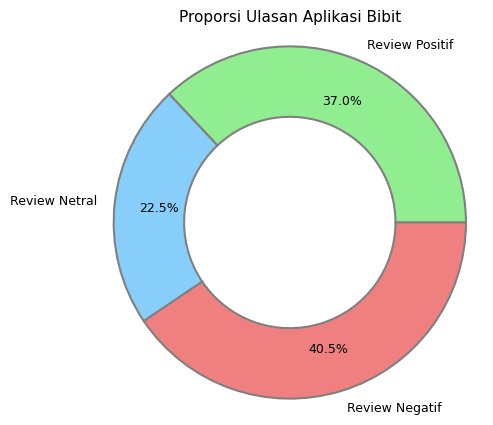

In [ ]:
import matplotlib.pyplot as plt

# Urutan label
order = ["positive", "neutral", "negative"]

# Hitung persentase
sentiment_percent = (
    df["sentiment"]
    .value_counts(normalize=True)
    .reindex(order) * 100
)

# Label tampilan
labels = ["Review Positif", "Review Netral", "Review Negatif"]

# Warna
colors = ["lightgreen", "lightskyblue", "lightcoral"]

# Figure
plt.figure(figsize=(5,5))

# Donut chart
wedges, texts, autotexts = plt.pie(
    sentiment_percent,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.75,   # posisi persen di dalam lingkaran
    startangle=0,
    wedgeprops={
        'width': 0.40,
        'edgecolor': 'gray',
        'linewidth': 1.5
    },
    textprops={'fontsize': 9}
)

# Mempercantik teks persentase
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)

# Judul
plt.title(
    "Proporsi Ulasan Aplikasi Bibit",
    fontsize=11
)

# Bentuk tetap bulat
plt.axis('equal')

plt.show()

split data

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/skripsi/bibit_reviews_labelled.csv")

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

label_map = {"positive": 0, "neutral": 1, "negative": 2}
df["label"] = df["sentiment"].map(label_map)

df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)
df_val, df_test = train_test_split(
    df_temp,
    test_size=2/3,
    stratify=df_temp["label"],
    random_state=42
)
X_train = df_train["normalisasi"].values
y_train = df_train["label"].values

X_val = df_val["normalisasi"].values
y_val = df_val["label"].values

X_test = df_test["normalisasi"].values
y_test = df_test["label"].values

print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)


Train: (6522, 21)
Val  : (932, 21)
Test : (1864, 21)


In [ ]:
#cek distribusi data train, test, dan val
print("\nDistribusi Train:")
print(df_train["sentiment"].value_counts(normalize=True))

print("\nDistribusi Val:")
print(df_val["sentiment"].value_counts(normalize=True))

print("\nDistribusi Test:")
print(df_test["sentiment"].value_counts(normalize=True))


Distribusi Train:
sentiment
negative    0.405397
positive    0.370132
neutral     0.224471
Name: proportion, dtype: float64

Distribusi Val:
sentiment
negative    0.405579
positive    0.370172
neutral     0.224249
Name: proportion, dtype: float64

Distribusi Test:
sentiment
negative    0.405579
positive    0.369635
neutral     0.224785
Name: proportion, dtype: float64


SMOTE

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import pandas as pd

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vect = vectorizer.fit_transform(X_train).toarray()

# SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_vect, y_train)

# Cek distribusi
print("Distribusi label setelah SMOTE:")
print(pd.Series(y_train_bal).value_counts())

Distribusi label setelah SMOTE:
0    3893
2    3893
1    3893
Name: count, dtype: int64


#IndoBERT

In [ ]:
!pip install transformers torch pandas scikit-learn tqdm seaborn

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.metrics import accuracy_score, f1_score

set seed

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data

In [ ]:
print("Distribusi data:")
print(df_train["label"].value_counts())

Distribusi data:
label
2    2644
0    2414
1    1464
Name: count, dtype: int64


tokenizer

In [ ]:
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
MAX_LEN = 256

def tokenize_texts(texts):
    return tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

In [ ]:
train_encodings = tokenize_texts(df_train["normalisasi"])
val_encodings   = tokenize_texts(df_val["normalisasi"])
test_encodings  = tokenize_texts(df_test["normalisasi"])

dataset class

In [ ]:
class BertDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [ ]:
train_dataset = BertDataset(train_encodings, df_train["label"].values)
val_dataset   = BertDataset(val_encodings, df_val["label"].values)
test_dataset  = BertDataset(test_encodings, df_test["label"].values)

data loader

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

bert classifier

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

model.to(device)

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
def tampilkan_proses_indobert(text, tokenizer, model, device):
    model.eval()

    # Tokenisasi
    encoding = tokenizer(
        text,
        return_tensors='pt',
        padding=False,
        truncation=True,
        return_token_type_ids=True
    )

    input_ids = encoding['input_ids'].to(device)

    # ambil token_type_ids (segment)
    token_type_ids = encoding.get('token_type_ids')
    if token_type_ids is not None:
        segment_ids = token_type_ids[0].cpu().tolist()
    else:
        segment_ids = None  # kalau model tidak pakai (misal RoBERTa)

    # Token (dengan CLS & SEP)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())

    # Hilangkan CLS & SEP untuk word tokenizing
    tokens_no_special = tokens[1:-1]

    # Token ID
    token_ids = input_ids[0].cpu().tolist()

    # Position (otomatis dari panjang token)
    position_ids = list(range(1, len(token_ids) + 1))

    # Output
    print("Original")
    print(text)

    print("\nToken Khusus")
    print("[CLS] + " + " ".join(tokens_no_special) + " + [SEP]")

    print("\nWord Tokenizing")
    print(tokens_no_special)

    print("\nToken Embedding")
    print(token_ids)

    print("\nSegmen Embedding")
    print(segment_ids)

    print("\nPosition Embedding")
    print(position_ids)

In [ ]:
sample_text = df_train["normalisasi"].iloc[0]

tampilkan_proses_indobert(sample_text, tokenizer, model, device)

Original
sudah hampir seminggu terhenti ditampilan awal tidak bisa terbuka sama sekali padahal lagi butuh untuk pencairan dana sudah install ulang beberapa kali tetap tidak bisa agak kecewa sih

Token Khusus
[CLS] + sudah hampir seminggu terhenti dita ##mp ##ilan awal tidak bisa terbuka sama sekali padahal lagi butuh untuk pencairan dana sudah install ulang beberapa kali tetap tidak bisa agak kecewa sih + [SEP]

Word Tokenizing
['sudah', 'hampir', 'seminggu', 'terhenti', 'dita', '##mp', '##ilan', 'awal', 'tidak', 'bisa', 'terbuka', 'sama', 'sekali', 'padahal', 'lagi', 'butuh', 'untuk', 'pencairan', 'dana', 'sudah', 'install', 'ulang', 'beberapa', 'kali', 'tetap', 'tidak', 'bisa', 'agak', 'kecewa', 'sih']

Token Embedding
[2, 259, 1856, 6452, 16504, 18154, 3425, 1021, 1343, 119, 166, 2781, 500, 684, 2234, 423, 2655, 90, 16223, 1869, 259, 7786, 2420, 388, 633, 830, 119, 166, 2839, 6743, 1966, 3]

Segmen Embedding
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

optimizer, loss, & scheduler

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-6)
EPOCHS = 5

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

training function

In [ ]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()

    losses = []
    preds = []
    labels_all = []

    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # backward
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        losses.append(loss.item())

        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average='weighted')
    loss_mean = np.mean(losses)

    return acc, f1, loss_mean

evaluation function

In [ ]:
def eval_model(model, data_loader, device):
    model.eval()

    losses = []
    preds = []
    labels_all = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            losses.append(loss.item())

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average='weighted')
    loss_mean = np.mean(losses)

    return acc, f1, loss_mean

training loop

In [ ]:
history = defaultdict(list)
best_f1 = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 50)

    train_acc, train_f1, train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )

    val_acc, val_f1, val_loss = eval_model(
        model, val_loader, device
    )

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    # simpan history
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['train_loss'].append(train_loss)

    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_loss'].append(val_loss)

    # simpan best model berdasarkan F1 validation
    if val_f1 > best_f1:
        torch.save(model.state_dict(), "best_model.bin")
        best_f1 = val_f1
        print("Model terbaik disimpan")


Epoch 1/5
--------------------------------------------------
Train Loss: 0.7730 | Acc: 0.6533 | F1: 0.6554
Val   Loss: 0.3380 | Acc: 0.8788 | F1: 0.8767
Model terbaik disimpan

Epoch 2/5
--------------------------------------------------
Train Loss: 0.2777 | Acc: 0.9010 | F1: 0.9001
Val   Loss: 0.1943 | Acc: 0.9270 | F1: 0.9272
Model terbaik disimpan

Epoch 3/5
--------------------------------------------------
Train Loss: 0.1802 | Acc: 0.9344 | F1: 0.9342
Val   Loss: 0.1563 | Acc: 0.9442 | F1: 0.9438
Model terbaik disimpan

Epoch 4/5
--------------------------------------------------
Train Loss: 0.1444 | Acc: 0.9500 | F1: 0.9498
Val   Loss: 0.1424 | Acc: 0.9453 | F1: 0.9456
Model terbaik disimpan

Epoch 5/5
--------------------------------------------------
Train Loss: 0.1195 | Acc: 0.9626 | F1: 0.9626
Val   Loss: 0.1355 | Acc: 0.9496 | F1: 0.9495
Model terbaik disimpan


In [ ]:
model.load_state_dict(torch.load("best_model.bin"))

test_acc, test_f1, test_loss = eval_model(model, test_loader, device)

print("\nHasil Test")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")


Hasil Test
Test Loss: 0.1711
Test Accuracy: 0.9222
Test F1 Score: 0.9219


model evaluation

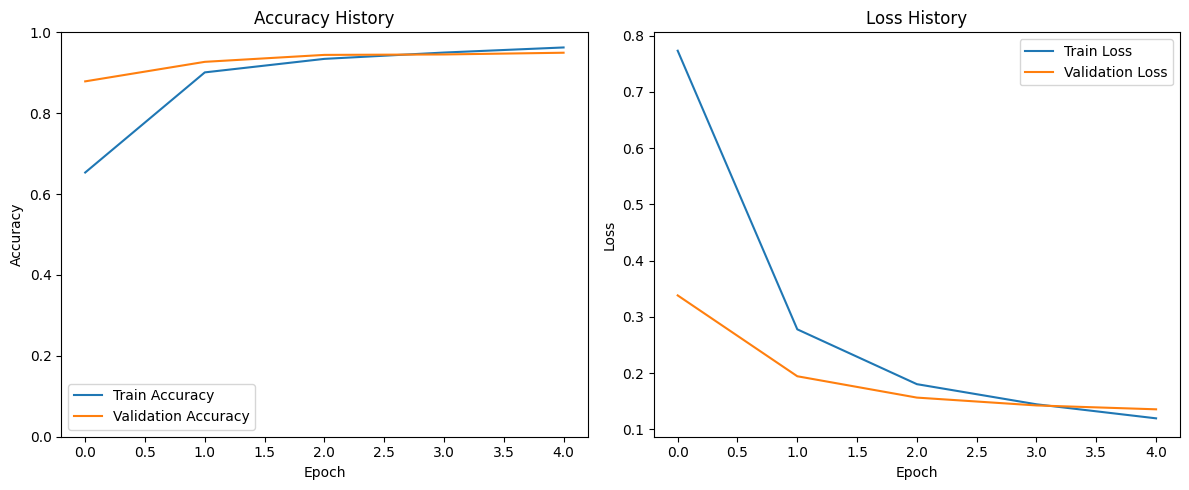

In [ ]:
plt.figure(figsize=(12,5))

# subplot 1 → Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()

# subplot 2 → Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def get_predictions(model, data_loader, device):
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels

classification report

In [ ]:
y_pred, y_true = get_predictions(model, test_loader, device)

print("\nClassification Report Testing Data")
print(classification_report(y_true, y_pred, target_names=["positif","netral","negatif"]))


Classification Report Testing Data
              precision    recall  f1-score   support

     positif       0.94      0.96      0.95       689
      netral       0.88      0.84      0.86       419
     negatif       0.93      0.93      0.93       756

    accuracy                           0.92      1864
   macro avg       0.92      0.91      0.91      1864
weighted avg       0.92      0.92      0.92      1864



In [ ]:
y_pred_train, y_train_true = get_predictions(model, train_loader, device)

print("\nClassification Report Training Data")
print(classification_report(y_train_true,y_pred_train,target_names=["positif", "netral", "negatif"]))


Classification Report Training Data
              precision    recall  f1-score   support

     positif       0.98      0.99      0.99      2414
      netral       0.97      0.95      0.96      1464
     negatif       0.98      0.98      0.98      2644

    accuracy                           0.98      6522
   macro avg       0.98      0.97      0.98      6522
weighted avg       0.98      0.98      0.98      6522



In [ ]:
y_pred_val, y_val_true = get_predictions(model, val_loader, device)

print("\nClassification Report Validation Data")
print(classification_report(y_val_true,y_pred_val,target_names=["positif", "netral", "negatif"]))


Classification Report Validation Data
              precision    recall  f1-score   support

     positif       0.96      0.97      0.97       345
      netral       0.90      0.89      0.90       209
     negatif       0.97      0.96      0.96       378

    accuracy                           0.95       932
   macro avg       0.94      0.94      0.94       932
weighted avg       0.95      0.95      0.95       932



confusion matrix

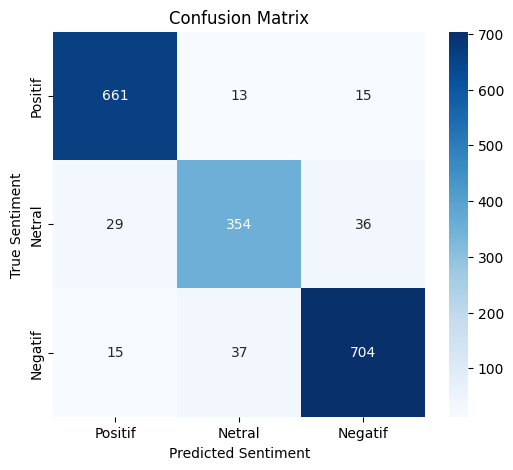

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ["Positif", "Netral", "Negatif"]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.title("Confusion Matrix")
plt.show()

Prediksi Ulasan Baru

In [ ]:
def predict_batch_with_score(texts, model, tokenizer, device, batch_size=16):
    model.eval()

    all_preds = []
    all_scores = []

    label_map = {0: "positif", 1: "netral", 2: "negatif"}

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        encoding = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=256
        )

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        for j in range(len(preds)):
            label = label_map[preds[j].item()]
            score = probs[j][preds[j]].item()

            all_preds.append(label)
            all_scores.append(score)

    return all_preds, all_scores

In [ ]:
ulasan_baru = [
    "kecewa sama aplikasi nya, mau masuk dr pagi dibuka sampai sore gak bisa masuk, selalu jaringan tidak stabil, sedangkan aplikasi laen semua bisa dibuka gak ada masalah apapun",
    "sangat baik dan membantu. ulasan tambahan adalah inilah aplikasi yg membuat tidak ada kata terlambat untuk belajar,jadi seperti gen z masa kini walau masih tertatih-tatih",
    "sudah bagus dan mantap harapan nya semoga kedepan nya bisa ada fitur bibit international jadi ada pembelian saham luar negeri",
    "Awalnya nyaman2 aja pake bibit, namun ketika saya butuh menghubungi CS responnya lambat sekali, mau ngobrol live chat gak di layanin. Tolong untuk layanan CS di perbaiki.",
    "sebelumnya ga pernah nyalain fitur SIP tiba-tiba saya punya saldo terakhir hilang masuk ke bibit saya, katanya fitur SIP dan giliran mau saya tarik lagi gabisa dan itupun gabisa dibatalin juga"
]

In [ ]:
preds, scores = predict_batch_with_score(
    ulasan_baru, model, tokenizer, device
)

df_hasil = pd.DataFrame({
    "ulasan": ulasan_baru,
    "sentimen": preds,
    "score": scores
})

print(df_hasil)

                                              ulasan sentimen     score
0  kecewa sama aplikasi nya, mau masuk dr pagi di...  negatif  0.990088
1  sangat baik dan membantu. ulasan tambahan adal...  positif  0.989174
2  sudah bagus dan mantap harapan nya semoga kede...  positif  0.991923
3  Awalnya nyaman2 aja pake bibit, namun ketika s...  negatif  0.947137
4  sebelumnya ga pernah nyalain fitur SIP tiba-ti...  negatif  0.668860


#XLNet

In [ ]:
!pip install transformers torch pandas scikit-learn tqdm seaborn

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from torch.utils.data import TensorDataset, DataLoader
from transformers import XLNetTokenizer, XLNetForSequenceClassification
from torch.optim import AdamW
from tqdm import trange

device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


data

In [ ]:
print("Distribusi data:")
print(df_train["label"].value_counts())

Distribusi data:
label
2    2644
0    2414
1    1464
Name: count, dtype: int64


tokenisasi

In [ ]:
model_name = "xlnet-base-cased"
tokenizer = XLNetTokenizer.from_pretrained(model_name)
MAX_LEN = 256

# Split data train_balanced menjadi train dan validation
X_train, X_val, y_train, y_val = train_test_split(
    df_train["normalisasi"],
    df_train["label"],
    test_size=0.1,
    random_state=42,
    stratify=df_train["label"]
)

# fungsi tokenisasi
def tokenize_texts(texts, tokenizer, max_len=MAX_LEN):
    encoding = tokenizer(
        texts.tolist() if isinstance(texts, pd.Series) else texts,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    return encoding['input_ids'], encoding['attention_mask']

# tokenisasi
train_inputs, train_masks = tokenize_texts(X_train, tokenizer)
val_inputs, val_masks     = tokenize_texts(X_val, tokenizer)
test_inputs, test_masks   = tokenize_texts(df_test["normalisasi"], tokenizer)

# label → tensor
train_labels = torch.tensor(y_train.values, dtype=torch.long)
val_labels   = torch.tensor(y_val.values, dtype=torch.long)
test_labels  = torch.tensor(df_test["label"].values, dtype=torch.long)

In [ ]:
# contoh tokenisasi
text = df_train.iloc[0]["normalisasi"]

tokens = tokenizer.tokenize(text)
inputs = tokenizer(text, padding="max_length", truncation=True, max_length=30)

print("Teks:", text)
print("Tokens:", tokens)
print("Input IDs:", inputs["input_ids"])
print("Attention Mask:", inputs["attention_mask"])

Teks: sudah hampir seminggu terhenti ditampilan awal tidak bisa terbuka sama sekali padahal lagi butuh untuk pencairan dana sudah install ulang beberapa kali tetap tidak bisa agak kecewa sih
Tokens: ['▁', 'su', 'dah', '▁', 'ham', 'pir', '▁semi', 'ng', 'gu', '▁', 'ter', 'h', 'enti', '▁', 'dit', 'amp', 'il', 'an', '▁a', 'wal', '▁', 'tid', 'ak', '▁bi', 'sa', '▁', 'ter', 'bu', 'ka', '▁', 's', 'ama', '▁', 's', 'ek', 'ali', '▁pad', 'ah', 'al', '▁la', 'gi', '▁but', 'uh', '▁', 'unt', 'uk', '▁pen', 'cai', 'ran', '▁', 'd', 'ana', '▁', 'su', 'dah', '▁install', '▁', 'ul', 'ang', '▁be', 'ber', 'apa', '▁', 'ka', 'li', '▁', 'te', 't', 'ap', '▁', 'tid', 'ak', '▁bi', 'sa', '▁', 'aga', 'k', '▁', 'ke', 'ce', 'wa', '▁', 's', 'ih']
Input IDs: [17, 3192, 12280, 17, 1714, 9261, 3233, 3511, 3017, 17, 1158, 409, 14207, 17, 8159, 1701, 902, 262, 24, 9760, 17, 19408, 1410, 5854, 1512, 17, 1158, 3494, 4, 3]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


data loader

In [ ]:
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
val_dataset   = TensorDataset(val_inputs, val_masks, val_labels)
test_dataset  = TensorDataset(test_inputs, test_masks, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

model

In [ ]:
model = XLNetForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

model.to(device)

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLNetForSequenceClassification(
  (transformer): XLNetModel(
    (word_embedding): Embedding(32000, 768)
    (layer): ModuleList(
      (0-11): 12 x XLNetLayer(
        (rel_attn): XLNetRelativeAttention(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): XLNetFeedForward(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (layer_1): Linear(in_features=768, out_features=3072, bias=True)
          (layer_2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation_function): GELUActivation()
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (sequence_summary): XLNetSequenceSummary(
    (summary): Linear(in_features=768, out_features=768, bias=True)
    (activation): Tanh()
    (first_dropout): Identity()
    

optimizer

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 5

fungsi akurasi

In [ ]:
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1)
    return np.sum(pred_flat == labels) / len(labels)

training function

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    preds_all, labels_all = [], []

    for batch in data_loader:
        b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]

        optimizer.zero_grad()

        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = logits.argmax(dim=1).detach().cpu().numpy()
        labels = b_labels.detach().cpu().numpy()

        preds_all.extend(preds)
        labels_all.extend(labels)

    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='weighted')

    return acc, f1, total_loss / len(data_loader)

evaluation function

In [ ]:
def eval_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for batch in data_loader:
            b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]

            outputs = model(
                input_ids=b_input_ids,
                attention_mask=b_input_mask,
                labels=b_labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = logits.argmax(dim=1).detach().cpu().numpy()
            labels = b_labels.detach().cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels)

    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='weighted')

    return acc, f1, total_loss / len(data_loader)

training loop

In [ ]:
from collections import defaultdict
import torch
from transformers import get_linear_schedule_with_warmup

history = defaultdict(list)
best_f1 = 0

# Define scheduler
total_steps_xlnet = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps_xlnet),
    num_training_steps=total_steps_xlnet
)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-" * 50)

    train_acc, train_f1, train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_acc, val_f1, val_loss = eval_model(model, val_loader, device)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    # simpan history
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['train_loss'].append(train_loss)

    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_loss'].append(val_loss)

    # simpan best model
    if val_f1 > best_f1:
        torch.save(model.state_dict(), "best_model_xlnet.bin")
        best_f1 = val_f1
        print("Model terbaik disimpan")


Epoch 1/5
--------------------------------------------------
Train Loss: 0.8899 | Acc: 0.5672 | F1: 0.5392
Val   Loss: 0.6783 | Acc: 0.7335 | F1: 0.7221
Model terbaik disimpan

Epoch 2/5
--------------------------------------------------
Train Loss: 0.6103 | Acc: 0.7441 | F1: 0.7360
Val   Loss: 0.5556 | Acc: 0.7672 | F1: 0.7540
Model terbaik disimpan

Epoch 3/5
--------------------------------------------------
Train Loss: 0.4821 | Acc: 0.8088 | F1: 0.8067
Val   Loss: 0.4895 | Acc: 0.8040 | F1: 0.7998
Model terbaik disimpan

Epoch 4/5
--------------------------------------------------
Train Loss: 0.3952 | Acc: 0.8421 | F1: 0.8406
Val   Loss: 0.4919 | Acc: 0.8147 | F1: 0.8086
Model terbaik disimpan

Epoch 5/5
--------------------------------------------------
Train Loss: 0.3447 | Acc: 0.8644 | F1: 0.8632
Val   Loss: 0.5213 | Acc: 0.8239 | F1: 0.8182
Model terbaik disimpan


In [ ]:
model.load_state_dict(torch.load('best_model_xlnet.bin'))

test_loss, test_acc, test_f1 = eval_model(
    model, test_loader, device
)

print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Test Loss    : 0.8171
Test Accuracy: 0.8089
Test F1 Score: 0.5065


validasi

In [ ]:
model.eval()
eval_accuracy = 0

for batch in val_loader:
    b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]

    with torch.no_grad():
        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_input_mask
        )

    logits = outputs.logits.cpu().numpy()
    label_ids = b_labels.cpu().numpy()
    eval_accuracy += flat_accuracy(logits, label_ids)

print(f"Validation Accuracy: {eval_accuracy / len(val_loader):.4f}")

Validation Accuracy: 0.8223


model evaluation

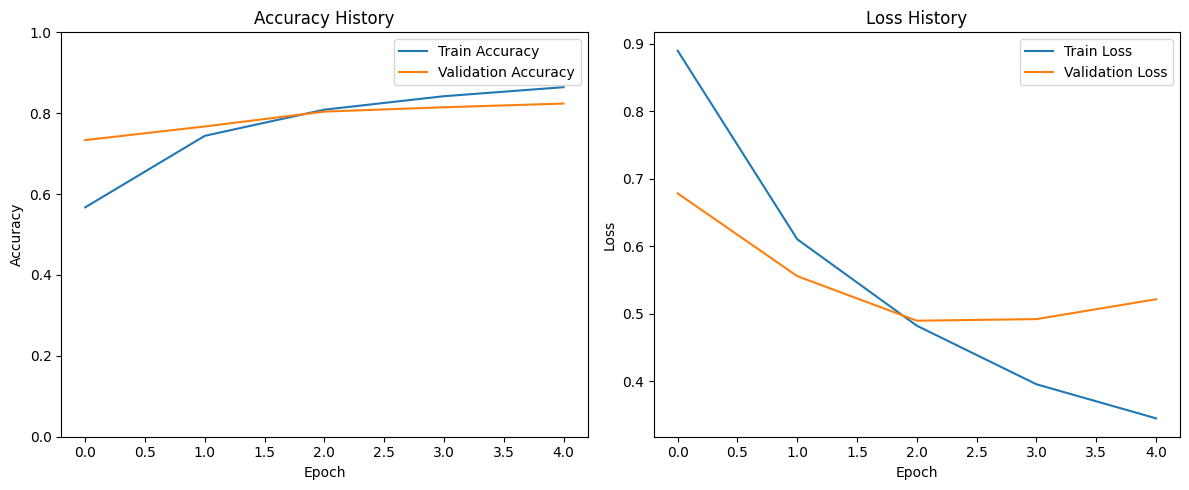

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def get_predictions(model, data_loader, device):
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels

klasifikasi report

In [ ]:
predictions, true_labels = get_predictions(model, test_loader, device)

print("\nClassification Report Testing Data")
print(classification_report(true_labels,predictions,target_names=["positif", "netral", "negatif"]))


Classification Report Testing Data
              precision    recall  f1-score   support

     positif       0.83      0.92      0.87       689
      netral       0.78      0.53      0.63       419
     negatif       0.82      0.88      0.85       756

    accuracy                           0.82      1864
   macro avg       0.81      0.78      0.78      1864
weighted avg       0.81      0.82      0.81      1864



In [ ]:
train_pred, train_true = get_predictions(model, train_loader, device)

print("\nClassification Report Training Data")
print(classification_report(train_true,train_pred,target_names=["positif", "netral", "negatif"]))


Classification Report Training Data
              precision    recall  f1-score   support

     positif       0.92      0.96      0.94      2172
      netral       0.91      0.71      0.80      1318
     negatif       0.87      0.94      0.91      2379

    accuracy                           0.90      5869
   macro avg       0.90      0.87      0.88      5869
weighted avg       0.90      0.90      0.89      5869



In [ ]:
val_true, val_pred = get_predictions(model, val_loader, device)

print("\nClassification Report (Validation Data")
print(classification_report(val_true,val_pred,target_names=["positif", "netral", "negatif"]))


Classification Report (Validation Data
              precision    recall  f1-score   support

     positif       0.89      0.83      0.86       259
      netral       0.58      0.82      0.68       104
     negatif       0.89      0.82      0.85       290

    accuracy                           0.82       653
   macro avg       0.79      0.82      0.80       653
weighted avg       0.84      0.82      0.83       653



confusion matrix

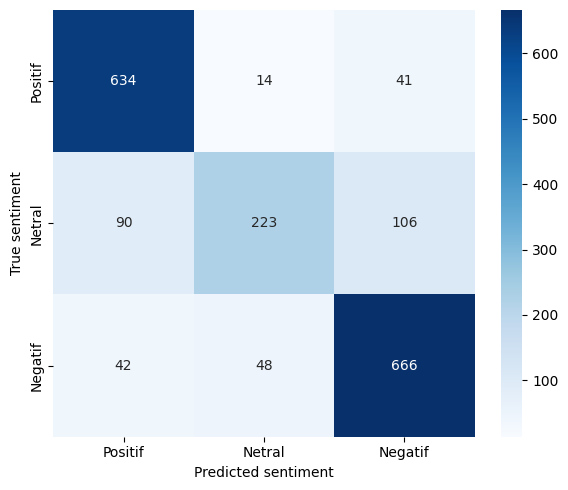

In [ ]:
class_names = ["Positif", "Netral", "Negatif"]
cm_xlnet = confusion_matrix(true_labels, predictions)
df_cm = pd.DataFrame(cm_xlnet, index=class_names, columns=class_names)

plt.figure(figsize=(6,5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel("True sentiment")
plt.xlabel("Predicted sentiment")
plt.tight_layout()
plt.show()

Prediksi Data Baru

In [ ]:
def predict_xlnet(texts, model, tokenizer, device, max_len=256, batch_size=16):
    model.eval()

    all_preds = []
    all_scores = []

    label_map = {0: "positif", 1: "netral", 2: "negatif"}

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encoding = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        for j in range(len(preds)):
            all_preds.append(label_map[preds[j].item()])
            all_scores.append(probs[j][preds[j]].item())

    return all_preds, all_scores

In [ ]:
ulasan_baru = [
    "kecewa sama aplikasi nya, mau masuk dr pagi dibuka sampai sore gak bisa masuk, selalu jaringan tidak stabil, sedangkan aplikasi laen semua bisa dibuka gak ada masalah apapun",
    "sangat baik dan membantu. ulasan tambahan adalah inilah aplikasi yg membuat tidak ada kata terlambat untuk belajar,jadi seperti gen z masa kini walau masih tertatih-tatih",
    "sudah bagus dan mantap harapan nya semoga kedepan nya bisa ada fitur bibit international jadi ada pembelian saham luar negeri",
    "Awalnya nyaman2 aja pake bibit, namun ketika saya butuh menghubungi CS responnya lambat sekali, mau ngobrol live chat gak di layanin. Tolong untuk layanan CS di perbaiki.",
    "sebelumnya ga pernah nyalain fitur SIP tiba-tiba saya punya saldo terakhir hilang masuk ke bibit saya, katanya fitur SIP dan giliran mau saya tarik lagi gabisa dan itupun gabisa dibatalin juga"
]

In [ ]:
preds, scores = predict_xlnet(
    ulasan_baru, model, tokenizer, device
)

df_hasil = pd.DataFrame({
    "ulasan": ulasan_baru,
    "sentimen": preds,
    "score": scores
})

print(df_hasil)

                                              ulasan sentimen     score
0  kecewa sama aplikasi nya, mau masuk dr pagi di...  negatif  0.969224
1  sangat baik dan membantu. ulasan tambahan adal...  positif  0.932181
2  sudah bagus dan mantap harapan nya semoga kede...  positif  0.997044
3  Awalnya nyaman2 aja pake bibit, namun ketika s...  negatif  0.963595
4  sebelumnya ga pernah nyalain fitur SIP tiba-ti...  negatif  0.529533


In [ ]:
print(df_train.index[0])

1173


#BERTopic

In [ ]:
!pip install bertopic sentence-transformers hdbscan umap-learn wordcloud Sastrawi gensim

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import numpy as np
import torch
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from transformers import AutoTokenizer, AutoModel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.7 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

load dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/skripsi/bibit_reviews_labelled.csv")
documents = df["stopword"].astype(str).tolist()

In [ ]:
sample_text = documents[1173]

print("\nContoh Dokumen")
print(sample_text)


Contoh Dokumen
hampir seminggu terhenti ditampilan awal terbuka sama butuh pencairan dana install ulang beberapa kali tetap kecewa


document embedding

In [ ]:
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(50000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
def tampilkan_embedding_indobert(text):
    encoding = tokenizer(text, return_tensors="pt", truncation=True).to(device)

    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0].cpu())
    token_ids = encoding["input_ids"][0].cpu().tolist()

    print("\n=== PROSES INDOBERT ===")
    print("Original:")
    print(text)

    print("\nToken Khusus:")
    print("[CLS] + " + " ".join(tokens[1:-1]) + " + [SEP]")

    print("\nWord Tokenizing:")
    print(tokens[1:-1])

    print("\nToken Embedding:")
    print(token_ids)

    print("\nPosition Embedding:")
    print(list(range(1, len(token_ids)+1)))

In [ ]:
tampilkan_embedding_indobert(sample_text)


=== PROSES INDOBERT ===
Original:
hampir seminggu terhenti ditampilan awal terbuka sama butuh pencairan dana install ulang beberapa kali tetap kecewa

Token Khusus:
[CLS] + ham pir ▁semi ng gu ▁ ter h enti ▁ dit amp il an ▁a wal ▁ ter bu ka ▁ s ama ▁but uh ▁pen cai ran ▁ d ana ▁install ▁ ul ang ▁be ber apa ▁ ka li ▁ te t ap ▁ ke ce wa <sep> + [SEP]

Word Tokenizing:
['ham', 'pir', '▁semi', 'ng', 'gu', '▁', 'ter', 'h', 'enti', '▁', 'dit', 'amp', 'il', 'an', '▁a', 'wal', '▁', 'ter', 'bu', 'ka', '▁', 's', 'ama', '▁but', 'uh', '▁pen', 'cai', 'ran', '▁', 'd', 'ana', '▁install', '▁', 'ul', 'ang', '▁be', 'ber', 'apa', '▁', 'ka', 'li', '▁', 'te', 't', 'ap', '▁', 'ke', 'ce', 'wa', '<sep>']

Token Embedding:
[17, 1714, 9261, 3233, 3511, 3017, 17, 1158, 409, 14207, 17, 8159, 1701, 902, 262, 24, 9760, 17, 1158, 3494, 1041, 17, 23, 4587, 57, 3314, 6995, 16541, 2156, 17, 66, 1751, 5397, 17, 1797, 2075, 39, 2266, 14643, 17, 1041, 1258, 17, 775, 46, 3307, 17, 1235, 1138, 1829, 4, 3]

Position Embeddi

In [ ]:
#fungsi embedding
def get_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    #mean pooling
    embedding = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
    return embedding[0]

#embedding semua dokumen
embeddings = np.array([get_embedding(doc) for doc in documents])

In [ ]:
print("\nProses Embedding Semua Dokumen")

print("Shape embedding:", embeddings.shape)
print("Contoh embedding (5 dimensi pertama):")
print(embeddings[0][:5])


Proses Embedding Semua Dokumen
Shape embedding: (9318, 768)
Contoh embedding (5 dimensi pertama):
[0.153886   0.80003047 0.12057833 0.09821278 0.37285125]


reduksi dimensi

In [ ]:
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

clustering topik

In [ ]:
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

tokenisasi & vektorisasi

In [ ]:
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    max_df=0.95
)

model

In [ ]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

fit & transform bertopic

In [ ]:
topics, probabilities = topic_model.fit_transform(documents, embeddings)
topic_model.reduce_topics(documents, nr_topics=10)

2026-05-16 09:02:12,044 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 09:03:16,427 - BERTopic - Dimensionality - Completed ✓
2026-05-16 09:03:16,429 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 09:03:17,253 - BERTopic - Cluster - Completed ✓
2026-05-16 09:03:17,263 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 09:03:17,840 - BERTopic - Representation - Completed ✓
2026-05-16 09:03:18,057 - BERTopic - Topic reduction - Reducing number of topics
2026-05-16 09:03:18,082 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 09:03:18,705 - BERTopic - Representation - Completed ✓
2026-05-16 09:03:18,711 - BERTopic - Topic reduction - Reduced number of topics from 27 to 10


informasi topik

In [ ]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))

   Topic  Count                                          Name  \
0     -1   4719                     -1_lama_masuk_reksa_mudah   
1      0   2182                    0_dana_hari_lama_pencairan   
2      1    789                 1_membuka_bintang_error_kalau   
3      2    668       2_pemula_mudah_membantu_sangat membantu   
4      3    379              3_semoga_terima beri_terima_beri   
5      4    212      4_perbarui_membuka_dibuka_aplikasi bibit   
6      5    156                         5_data_ktp_foto_nomor   
7      6    127  6_layanan_pelanggan_layanan pelanggan_respon   
8      7     52        7_masa depan_masa_depan_investasi masa   
9      8     34   8_otoritas jasa_otoritas_jasa keuangan_jasa   

                                      Representation  \
0  [lama, masuk, reksa, mudah, pemula, beri, hari...   
1  [dana, hari, lama, pencairan, uang, masuk, kal...   
2  [membuka, bintang, error, kalau, jaringan, bar...   
3  [pemula, mudah, membantu, sangat membantu, bel...   
4  [

In [ ]:
topics_dict = topic_model.get_topics()
total_topics = len([t for t in topics_dict.keys() if t != -1])
print(f"\nTotal topik (tidak termasuk outlier): {total_topics}")


Total topik (tidak termasuk outlier): 9


koherensi topik

In [ ]:
# Tokenisasi sederhana untuk koherensi (split kata)
tokenized_docs = [doc.split() for doc in documents]

# Buat dictionary untuk gensim
dictionary = Dictionary(tokenized_docs)

# Ambil topik (exclude -1/outlier)
topic_words = []
topic_ids = []

for topic_id in topics_dict:
    if topic_id != -1:
        words = [word for word, _ in topics_dict[topic_id]]
        topic_words.append(words)
        topic_ids.append(topic_id)

# Hitung coherence per topik
coherence_per_topic = []

for i, words in enumerate(topic_words):
    if len(words) > 1:  # Minimal 2 kata untuk coherence
        cm = CoherenceModel(
            topics=[words],
            texts=tokenized_docs,
            dictionary=dictionary,
            coherence='c_v'
        )
        score = cm.get_coherence()
        coherence_per_topic.append(score)
        print(f"Topik {topic_ids[i]}: {score:.4f}")
    else:
        print(f"Topik {topic_ids[i]}: SKIP (kurang dari 2 kata)")
        coherence_per_topic.append(0.0)

# Rata-rata coherence (hanya topik valid)
valid_scores = [s for s in coherence_per_topic if s > 0]
if valid_scores:
    avg_coherence = sum(valid_scores) / len(valid_scores)
    print(f"\n=== Rata-rata Coherence (c_v) ===")
    print(f"{avg_coherence:.4f}")

Topik 0: 0.7662
Topik 1: 0.5142
Topik 2: 0.7200
Topik 3: 0.6243
Topik 4: 0.7630
Topik 5: 0.7928
Topik 6: 0.8133
Topik 7: 0.8203
Topik 8: 0.8906

=== Rata-rata Coherence (c_v) ===
0.7449


visualisasi

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_topics()     # overview
topic_model.visualize_barchart()  # topik dominan

wordcloud

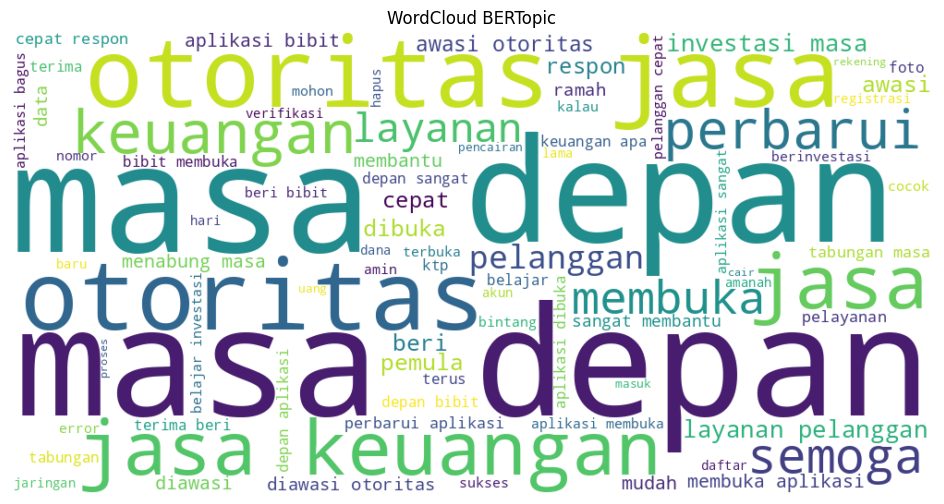

In [ ]:
freq = {}

topics_data = topic_model.get_topics() # Get the dictionary of topics

for topic_id, word_scores_list in topics_data.items():
    if topic_id == -1: # Optionally, skip the outlier topic (-1) if it's not relevant for the overall word cloud
        continue
    for word, score in word_scores_list:
        if word in freq:
            freq[word] += score
        else:
            freq[word] = score

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(freq)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud BERTopic")
plt.show()

In [ ]:
topic_model.visualize_barchart(top_n_topics=10)

In [ ]:
# Informasi topik
topic_info = topic_model.get_topic_info()

# tampilkan tabel distribusi topik
topic_distribution_bt = topic_info[['Topic', 'Count', 'Name']]

topic_distribution_bt

,Topic,Count,Name
0,-1,4719,-1_lama_masuk_reksa_mudah
1,0,2182,0_dana_hari_lama_pencairan
2,1,789,1_membuka_bintang_error_kalau
3,2,668,2_pemula_mudah_membantu_sangat membantu
4,3,379,3_semoga_terima beri_terima_beri
5,4,212,4_perbarui_membuka_dibuka_aplikasi bibit
6,5,156,5_data_ktp_foto_nomor
7,6,127,6_layanan_pelanggan_layanan pelanggan_respon
8,7,52,7_masa depan_masa_depan_investasi masa
9,8,34,8_otoritas jasa_otoritas_jasa keuangan_jasa


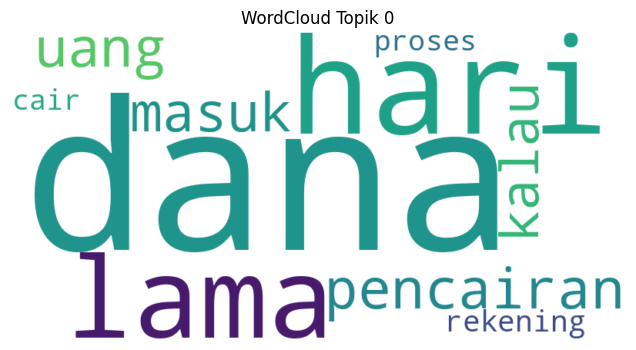

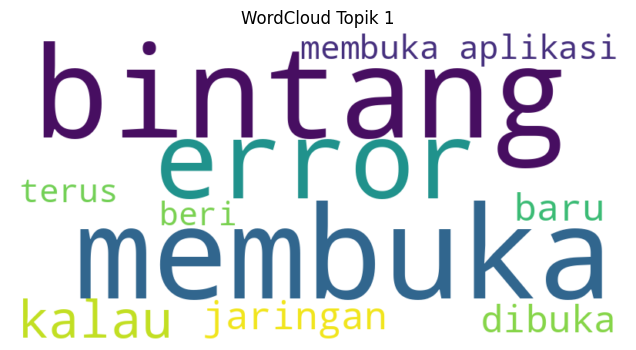

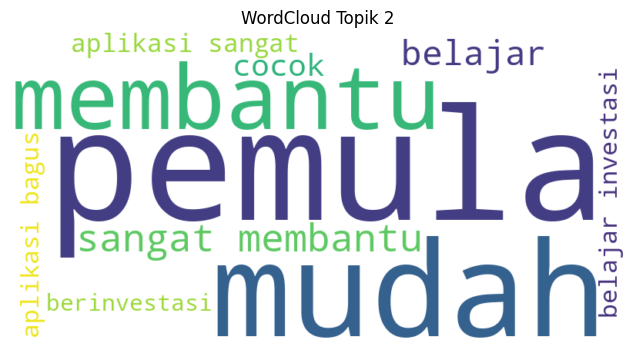

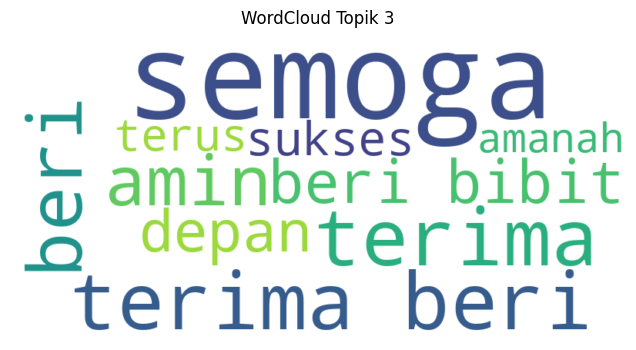

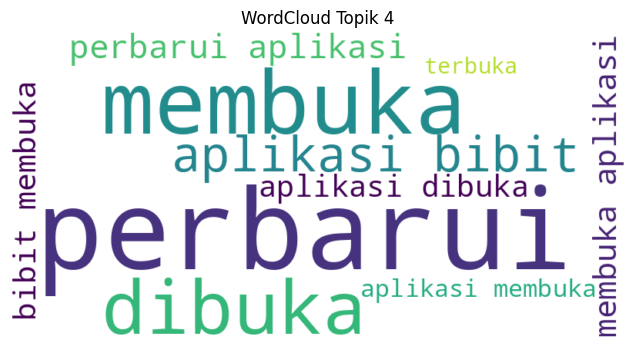

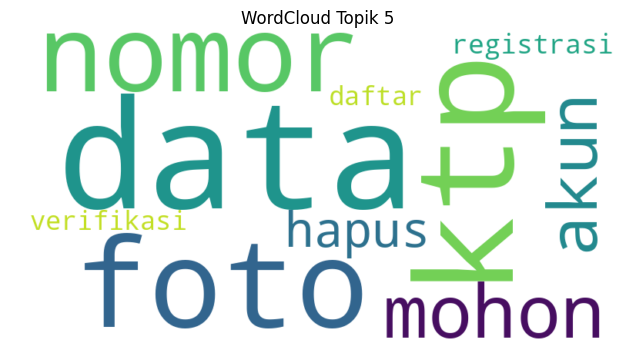

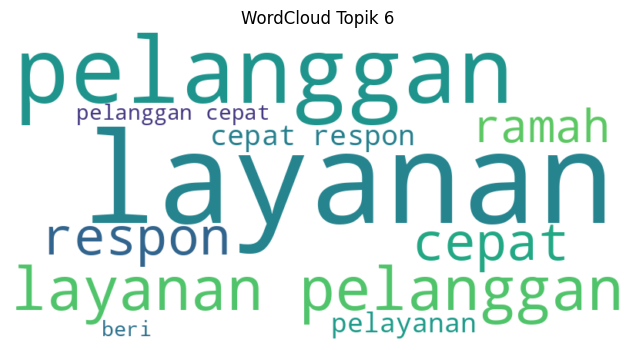

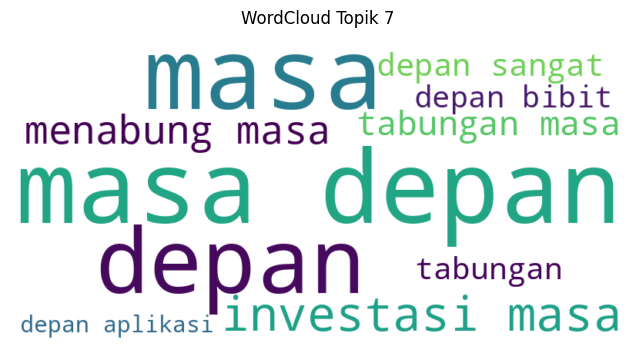

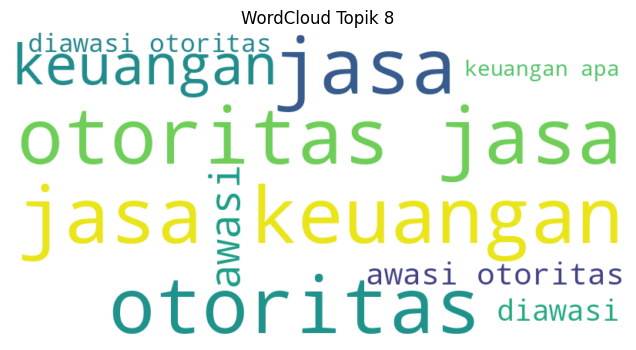

In [ ]:
top_topics = topic_info[topic_info["Topic"] != -1].head(9)["Topic"].tolist()
for topic_id in top_topics:
    words = dict(topic_model.get_topic(int(topic_id)))
    if words:
        wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis")
        wc.generate_from_frequencies(words)
        plt.figure(figsize=(8, 4))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"WordCloud Topik {topic_id}")
        plt.show()

dokumen per topik

In [ ]:
for topic_id in topic_info[topic_info["Topic"] != -1].head(15)["Topic"]:
    print(f"\nTOPIK {int(topic_id)}:")
    print("Kata kunci:", topic_model.get_topic(int(topic_id))[:10])

    representative_docs = topic_model.get_representative_docs(int(topic_id))
    if representative_docs:
        print("Contoh dokumen:", representative_docs[0][:200] + "..."
              if len(representative_docs[0]) > 200 else representative_docs[0])


TOPIK 0:
Kata kunci: [('dana', np.float64(0.0329648721705718)), ('hari', np.float64(0.0292743446200212)), ('lama', np.float64(0.026152610658890844)), ('pencairan', np.float64(0.022169339572410848)), ('uang', np.float64(0.021749165038939686)), ('masuk', np.float64(0.020905927254541996)), ('kalau', np.float64(0.020543034412470462)), ('rekening', np.float64(0.017126023189894538)), ('cair', np.float64(0.01633919938935485)), ('proses', np.float64(0.01623224879050731))]
Contoh dokumen: proses jual pencairan dana terlalu lama

TOPIK 1:
Kata kunci: [('membuka', np.float64(0.0494277314704231)), ('bintang', np.float64(0.04843269573975909)), ('error', np.float64(0.044548137037949874)), ('kalau', np.float64(0.031307322819893506)), ('jaringan', np.float64(0.031133534882118504)), ('baru', np.float64(0.02929401856135066)), ('dibuka', np.float64(0.028710172293647473)), ('membuka aplikasi', np.float64(0.027451241469094653)), ('terus', np.float64(0.02719008561568513)), ('beri', np.float64(0.02632451474

#Top2Vec

In [ ]:
!pip install top2vec gensim Sastrawi sentence-transformers

In [ ]:
from top2vec import Top2Vec
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

In [ ]:
import random
import numpy as np
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

load data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/skripsi/bibit_reviews_labelled.csv")
documents = df["stopword"].astype(str).tolist()

model

In [ ]:
embedding_model = SentenceTransformer('indobenchmark/indobert-base-p2')

def indobert_embedding(documents):
    return embedding_model.encode(documents, show_progress_bar=True)

In [ ]:
model = Top2Vec(
    documents=documents,
    embedding_model=indobert_embedding,
    min_count=25,
    speed="learn",
    workers=1,
    umap_args={'n_neighbors': 15, 'n_components': 5, 'metric': 'cosine'},
    hdbscan_args={'min_cluster_size': 15, 'metric': 'euclidean'}
)

2026-05-16 09:05:25,094 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
2026-05-16 09:05:26,012 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding


2026-05-16 09:06:08,961 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2026-05-16 09:06:35,927 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2026-05-16 09:06:36,292 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


jumlah topik

In [ ]:
num_topics = model.get_num_topics()
print(f"Jumlah Topik Awal: {num_topics}")

Jumlah Topik Awal: 2


kata representatif topik

In [ ]:
topic_words, word_scores, topic_nums = model.get_topics()

print("\nKata Representatif Tiap Topik:")
for i, words in zip(topic_nums, topic_words):
    print(f"Topik {i}: {words[:10]}")


Kata Representatif Tiap Topik:
Topik 0: ['mantap' 'bayar' 'banyak' 'menarik' 'baru' 'nyaman' 'bertambah' 'penting'
 'beli' 'susah']
Topik 1: ['kustodian' 'verifikasi' 'investor' 'transaksi' 'pembayaran' 'rekening'
 'crypto' 'pendaftaran' 'bursa' 'bca']


In [ ]:
topic_words_list, word_scores_list, topic_nums_list = model.get_topics()

print("\nKata Representatif Sebelum Reduksi:")

for i, topic_id in enumerate(topic_nums_list):
    # Ensure we don't access out of bounds for words and scores
    if i < len(topic_words_list) and i < len(word_scores_list):
        words = topic_words_list[i]
        scores = word_scores_list[i]

        print(f"\nTopik {topic_id}")

        # Ambil top 10 kata langsung (sudah terurut dari Top2Vec)
        for j in range(min(10, len(words))):
            print(f"{words[j]} ({scores[j]:.4f})")
    else:
        print(f"\nTopik {topic_id}: No words or scores available.")


Kata Representatif Sebelum Reduksi:

Topik 0
mantap (0.6369)
bayar (0.6255)
banyak (0.6196)
menarik (0.6180)
baru (0.6120)
nyaman (0.6090)
bertambah (0.6028)
penting (0.6011)
beli (0.6011)
susah (0.6004)

Topik 1
kustodian (0.4884)
verifikasi (0.4270)
investor (0.4027)
transaksi (0.4017)
pembayaran (0.3999)
rekening (0.3910)
crypto (0.3907)
pendaftaran (0.3886)
bursa (0.3877)
bca (0.3855)


ukuran topik

In [ ]:
topic_sizes, topic_nums = model.get_topic_sizes()

print("\nUkuran Tiap Topik:")
for size, num in zip(topic_sizes, topic_nums):
    print(f"Topik {num}: {size} dokumen")


Ukuran Tiap Topik:
Topik 0: 9203 dokumen
Topik 1: 115 dokumen


koherensi

In [ ]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

# tokenisasi
tokenized_docs = [doc.split() for doc in documents]

# dictionary
dictionary = Dictionary(tokenized_docs)

coherence_per_topic = []
calculated_topic_ids = []

# Iterate through the topic numbers and their corresponding words
for i, topic_num in enumerate(topic_nums):
    words = topic_words[i]  # Get the words for the current topic

    # Ensure there are enough words for coherence calculation
    if len(words) == 0: # Gensim CoherenceModel needs at least one word per topic
        print(f"Skipping topic {topic_num} due to insufficient words for coherence calculation.")
        continue

    cm = CoherenceModel(
        topics=[list(words)],  # Ensure words is a list of strings
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    score = cm.get_coherence()

    coherence_per_topic.append(score)
    calculated_topic_ids.append(topic_num)  # Use the actual topic number

print("\nCoherence per Topik (Sebelum Reduksi)")
for i, topic_id in enumerate(calculated_topic_ids):
    print(f"Topik {topic_id}: {coherence_per_topic[i]:.4f}")

if len(coherence_per_topic) > 0:
    avg_coherence = sum(coherence_per_topic) / len(coherence_per_topic)
    print("\nRata-rata Coherence:")
    print(f"{avg_coherence:.4f}")
else:
    print("\nTidak ada topik yang valid untuk perhitungan coherence.")


Coherence per Topik (Sebelum Reduksi)
Topik 0: 0.3329
Topik 1: 0.2969

Rata-rata Coherence:
0.3149


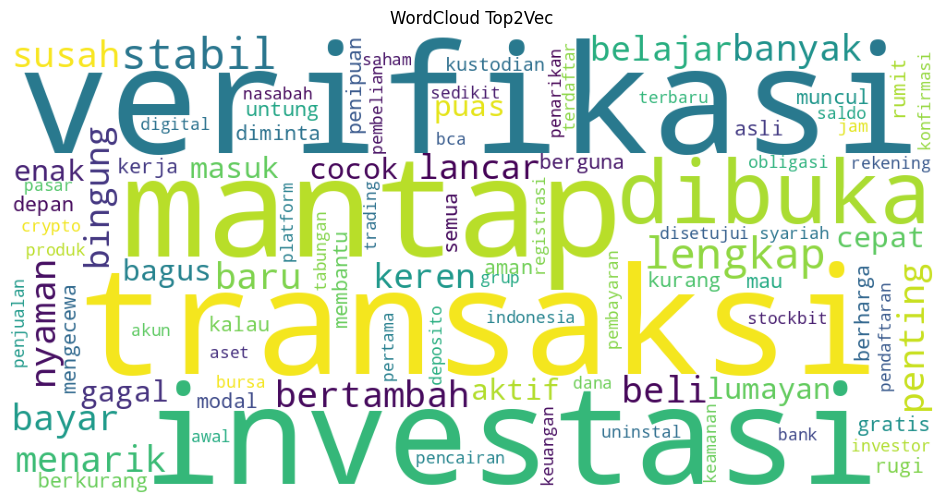

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ambil topik awal
# model.get_topics() returns (topic_words, word_scores, topic_nums)
topic_words_all, word_scores_all, topic_nums_all = model.get_topics()

freq = {}

# Iterate through each topic and its words/scores
for topic_idx in range(len(topic_nums_all)):
    words_for_current_topic = topic_words_all[topic_idx]
    scores_for_current_topic = word_scores_all[topic_idx]

    for word, score in zip(words_for_current_topic, scores_for_current_topic):
        # Accumulate scores for words across all topics
        freq[word] = freq.get(word, 0) + score

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
)

wc.generate_from_frequencies(freq)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud Top2Vec")
plt.show()

In [ ]:
topic_sizes, topic_nums = model.get_topic_sizes()

topic_distribution_t2v = pd.DataFrame({
    'Topic': topic_nums,
    'Count': topic_sizes
})

topic_distribution_t2v

,Topic,Count
0,0,9203
1,1,115


reduksi topik hierarkis

In [ ]:
target_topics = 10

reduced_topics=model.hierarchical_topic_reduction(num_topics=target_topics)
print(f"Jumlah Topik Setelah Reduksi: {len(reduced_topics)}")

Reducing topics: 100%|██████████| 35/35 [00:04<00:00,  8.40it/s]


Jumlah Topik Setelah Reduksi: 10


In [ ]:
#representasi kata topik
topic_words, word_scores, topic_nums = model.get_topics()

print("\nKata Representatif Setelah Reduksi:")
for i, topic_group in enumerate(reduced_topics):
    word_score_dict = {}

    for topic_id in topic_group:
        words = topic_words[topic_id]
        scores = word_scores[topic_id]

        for w, s in zip(words, scores):
            # kalau kata sama muncul lagi → ambil skor terbesar
            if w in word_score_dict:
                word_score_dict[w] = max(word_score_dict[w], s)
            else:
                word_score_dict[w] = s

    # urutkan berdasarkan skor tertinggi
    sorted_words = sorted(word_score_dict.items(), key=lambda x: x[1], reverse=True)

    # ambil top 10
    top_words = sorted_words[:10]

    print(f"\nTopik {i}")
    for w, s in top_words:
        print(f"{w} ({s:.4f})")


Kata Representatif Setelah Reduksi:

Topik 0
perbaiki (0.9419)
mencairkan (0.9315)
diperbaiki (0.9304)
ditingkatkan (0.9277)
dibuka (0.9273)
terpotong (0.9271)
diberi (0.9270)
diminta (0.9256)
dipakai (0.9228)
tingkatkan (0.9219)

Topik 1
perbarui (0.7688)
error (0.5869)
transaksinya (0.5698)
cairkan (0.5674)
gagal (0.5673)
baru (0.5665)
diperbaiki (0.5601)
hapus (0.5582)
diperbarui (0.5522)
aplikai (0.5487)

Topik 2
investasinya (0.7098)
pencairannya (0.7098)
transaksinya (0.6730)
penarikannya (0.6684)
beli (0.6588)
jual (0.6495)
cairnya (0.6405)
saham (0.6399)
baru (0.6372)
menguntungkan (0.6355)

Topik 3
investasinya (0.7409)
investasi (0.7108)
menguntungkan (0.6834)
aman (0.6482)
nyaman (0.6449)
modal (0.6230)
mantap (0.6218)
transaksinya (0.6216)
berinvestasi (0.6165)
menarik (0.6151)

Topik 4
pencairannya (0.6263)
transaksinya (0.5619)
penarikannya (0.5447)
cairkan (0.5415)
cairnya (0.5347)
investasinya (0.5160)
pembayaran (0.5126)
sebulan (0.5093)
bayar (0.5013)
seminggu (0.500

In [ ]:
#ukuran topik
size_dict = dict(zip(topic_nums, topic_sizes))

print("\nUkuran Topik Setelah Reduksi:")
for i, topic_group in enumerate(reduced_topics):
    total_size = sum(size_dict[topic_id] for topic_id in topic_group)
    print(f"Topik {i}: {total_size} dokumen")


Ukuran Topik Setelah Reduksi:
Topik 0: 1469 dokumen
Topik 1: 1178 dokumen
Topik 2: 1846 dokumen
Topik 3: 1010 dokumen
Topik 4: 805 dokumen
Topik 5: 474 dokumen
Topik 6: 558 dokumen
Topik 7: 639 dokumen
Topik 8: 619 dokumen
Topik 9: 709 dokumen


In [ ]:
#koherensi
coherence_per_topic = []

print("\nCoherence Tiap Topik Setelah Reduksi:")

for i, words in enumerate(reduced_topics):
    cm = CoherenceModel(
        topics=[words],
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    score = cm.get_coherence()
    coherence_per_topic.append(score)

    print(f"Topik {i}: {score:.4f}")

avg_coherence_after = sum(coherence_per_topic) / len(coherence_per_topic)

print("\nRata-rata Coherence Setelah Reduksi:")
print(f"{avg_coherence_after:.4f}")


Coherence Tiap Topik Setelah Reduksi:
Topik 0: 0.7431
Topik 1: 0.7348
Topik 2: 0.7433
Topik 3: 0.8230
Topik 4: 0.9846
Topik 5: 1.0000
Topik 6: 1.0000
Topik 7: 0.6506
Topik 8: 0.7915
Topik 9: 0.9145

Rata-rata Coherence Setelah Reduksi:
0.8385


visualisasi

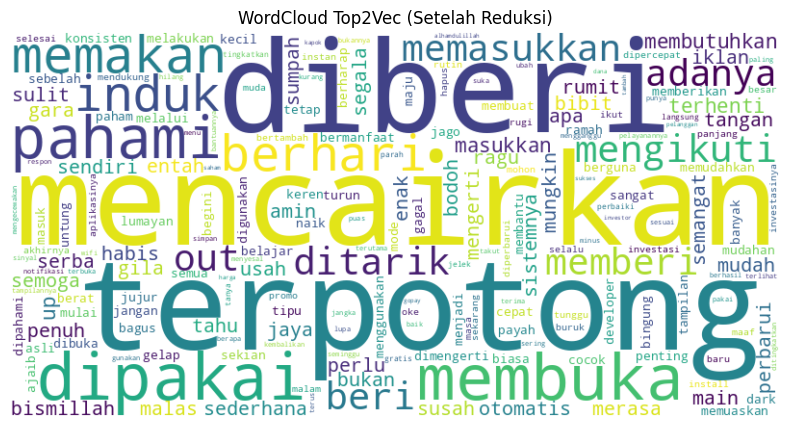

In [ ]:
reduced_topic_words = []
reduced_word_scores = []

for i, topic_group in enumerate(reduced_topics):
    word_score_dict = {}

    for topic_id in topic_group:
        words = topic_words[topic_id]
        scores = word_scores[topic_id]

        for w, s in zip(words, scores):
            # kalau kata sama muncul lagi → ambil skor terbesar
            if w in word_score_dict:
                word_score_dict[w] = max(word_score_dict[w], s)
            else:
                word_score_dict[w] = s

    # Urutkan dan ambil semua kata/skor untuk word cloud
    sorted_words = sorted(word_score_dict.items(), key=lambda x: x[1], reverse=True)
    words_for_group = [w for w, s in sorted_words]
    scores_for_group = [s for w, s in sorted_words]

    reduced_topic_words.append(words_for_group)
    reduced_word_scores.append(scores_for_group)


freq = {
    w: sc
    for words, scores in zip(reduced_topic_words, reduced_word_scores)
    for w, sc in zip(words, scores)
}

wc = WordCloud(background_color="white", width=800, height=400)\
    .generate_from_frequencies(freq)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Top2Vec (Setelah Reduksi)")
plt.show()